# Exercise 1
## Your task:
Create a *Personalized Compliment Agent* using LangGraph.

*Input:* `{"name": "Bob"}`
<br>
*Output:* `"Bob, you sure know how to circle them wagons!"`

In [1]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph


In [2]:
# We now create an AgentState - shared data structure that keeps track of information as your application runs.

class AgentState(TypedDict):
    message : str


def complimenting_node(state: AgentState) -> AgentState:
    """Node that appends compliment to the input message"""

    state['message'] += ', you sure know how to circle them wagons!'

    return state


In [3]:
graph = StateGraph(AgentState)

graph.add_node('complimenter', complimenting_node)


graph.set_entry_point('complimenter')
graph.set_finish_point('complimenter')

app = graph.compile()

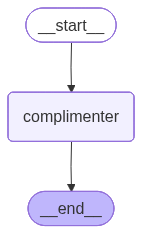

In [4]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [5]:
result = app.invoke({'message': 'Bibbidy Bob'})

In [6]:
result['message']

'Bibbidy Bob, you sure know how to circle them wagons!'